# Detectio Pipelie otebook

이 노트북은 `Detectio/sample_set` 기준으로 아래 순서를 단계별 실행합니다.

1. 이미지에서 ArUco 타겟 중심 탐지
2. 3D 라이다 좌표 변환과 `targets3d.jso` 생성
3. itensity 기반 중심 보정과 디버그 산출물 확인


In [ ]:
from pathlib import Path
import json
import shlex
import subprocess

import matplotlib.pyplot as plt
from PIL import Image

WORKSPACE = Path.cwd()
DETECTION = WORKSPACE / 'Detection'
if not (DETECTION / 'sample_set').exists():
    DETECTION = WORKSPACE

SAMPLE_SET = DETECTION / 'sample_set'
BUILD_DIR = DETECTION / 'build'
TARGET_TYPE = 'reference'
USE_FACE_MARKER = True
TARGET_SIZE_CM = 13

print('Detection root :', DETECTION)
print('Sample set      :', SAMPLE_SET)
print('Build dir       :', BUILD_DIR)

In [ ]:
import os
import shutil
import subprocess
from pathlib import Path

opencv_root = DETECTION / "opencv2"
opencv_include_root = opencv_root / "include"
opencv_include = opencv_include_root / "opencv2"
opencv_lib = opencv_root / "lib" / "opencv_world4.lib"
opencv_bin = opencv_root / "bin"

print("opencv_raw_include exists:", opencv_include_root.exists())
print("opencv_lib exists:", opencv_lib.exists())
print("opencv_bin exists:", opencv_bin.exists())

print("compat include root:", opencv_include_root)
print("test header exists:", (opencv_include / "objdetect" / "aruco_detector.hpp").exists())
print("test header exists:", (opencv_include / "core.hpp").exists())

if BUILD_DIR.exists():
    shutil.rmtree(BUILD_DIR)

configure = [
    "cmake",
    "-S", str(DETECTION),
    "-B", str(BUILD_DIR),
    f"-DDETECTION_OPENCV_INCLUDE_DIRS={opencv_include_root}",
    f"-DDETECTION_OPENCV_LIBRARIES={opencv_lib}",
]

print("CONFIGURE CMD:")
print(" ".join(configure))

result = subprocess.run(
    configure,
    cwd=DETECTION,
    text=True,
    capture_output=True
)
print("CONFIGURE RETURNCODE:", result.returncode)
print("----- CONFIGURE STDOUT -----")
print(result.stdout)
print("----- CONFIGURE STDERR -----")
print(result.stderr)
result.check_returncode()

build_cmd = ["cmake", "--build", str(BUILD_DIR), "--config", "Release"]

print("BUILD CMD:")
print(" ".join(build_cmd))

result = subprocess.run(
    build_cmd,
    cwd=DETECTION,
    text=True,
    capture_output=True
)
print("BUILD RETURNCODE:", result.returncode)
print("----- BUILD STDOUT -----")
print(result.stdout)
print("----- BUILD STDERR -----")
print(result.stderr)
result.check_returncode()

os.environ["PATH"] = str(opencv_bin) + os.pathsep + os.environ["PATH"]
print("PATH updated with:", opencv_bin)


opencv_raw_include exists: True
opencv_lib exists: True
opencv_bin exists: True


FileNotFoundError: [WinError 3] 지정된 경로를 찾을 수 없습니다: 'd:\\Conda_envs\\TargetDetection\\Detection\\opencv2\\include'

In [25]:
def find_runner():
    candidates = list(BUILD_DIR.rglob('DetectionRunner.exe')) + list(BUILD_DIR.rglob('DetectionRunner'))
    if not candidates:
        raise FileNotFoundError('DetectionRunner binary not found under build directory')
    return sorted(candidates, key=lambda path: (len(str(path)), str(path)))[0]

RUNNER = find_runner()
print('Runner :', RUNNER)

def run_stage(stage, *extra_args):
    cmd = [str(RUNNER), stage, str(SAMPLE_SET), TARGET_TYPE, *map(str, extra_args)]
    print(" ".join(shlex.quote(part) for part in cmd))

    env = os.environ.copy()
    env["PATH"] = str(DETECTION / "opencv2" / "bin") + os.pathsep + env["PATH"]

    result = subprocess.run(
        cmd,
        cwd=DETECTION,
        env=env,
        text=True,
        capture_output=True,
        check=True
    )
    if result.stdout.strip():
        print(result.stdout)
    if result.stderr.strip():
        print(result.stderr)
    return result

def show_json(path):
    path = Path(path)
    data = json.loads(path.read_text(encoding='utf-8'))
    print(json.dumps(data, indent=2, ensure_ascii=False))

def show_images(directory, pattern, cols=2, max_images=8, title_prefix=''):
    paths = sorted(Path(directory).glob(pattern))[:max_images]
    if not paths:
        print('No images found for pattern:', pattern)
        return

    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax in axes:
        ax.axis('off')

    for ax, path in zip(axes, paths):
        ax.imshow(Image.open(path))
        ax.set_title(f'{title_prefix}{path.name}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Runner : d:\Conda_envs\TargetDetection\Detection\build\Release\DetectionRunner.exe


'd:\Conda_envs\TargetDetection\Detection\build\Release\DetectionRunner.exe' detect 'd:\Conda_envs\TargetDetection\Detection\sample_set' reference
blast_path: d:\Conda_envs\TargetDetection\Detection\sample_set
target_type: reference
detect_dir: d:\Conda_envs\TargetDetection\Detection\sample_set\DetectTarget\reference
registration_dir: d:\Conda_envs\TargetDetection\Detection\sample_set\Registration\reference
input_images: 8
detect_json: 10
marked_images: 8
targets3d_json: d:\Conda_envs\TargetDetection\Detection\sample_set\Registration\reference\targets3d.json
targets3d_adjust_json: d:\Conda_envs\TargetDetection\Detection\sample_set\Registration\reference\targets3d_adjust.json
debug_dir: d:\Conda_envs\TargetDetection\Detection\sample_set\Registration\reference\debug

[PointCloudRegistration] Detected 0 aruco markers
[PointCloudRegistration] Detected 0 aruco markers
[PointCloudRegistration] Detected 0 aruco markers
[PointCloudRegistration] Detected 2 aruco markers
[PointCloudRegistration] 

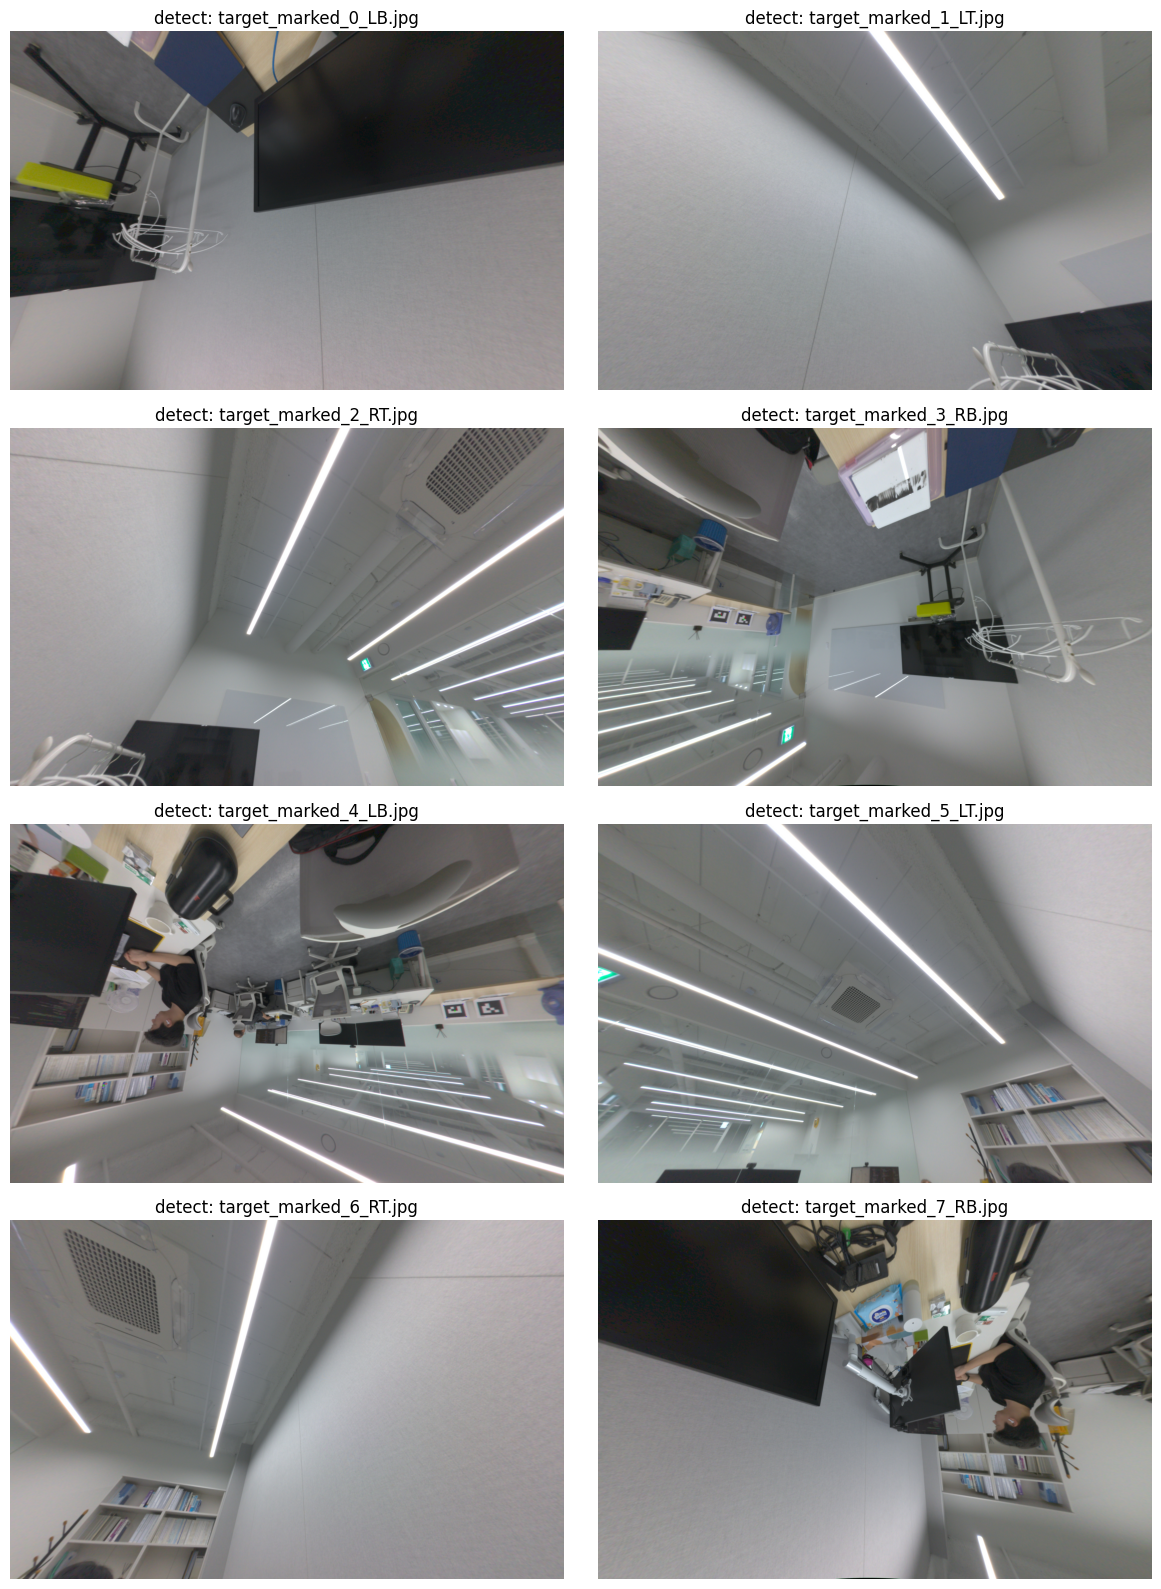

In [23]:
run_stage('detect')
show_images(SAMPLE_SET / 'DetectTarget' / TARGET_TYPE, 'target_marked_*.jpg', cols=2, max_images=8, title_prefix='detect: ')

In [ ]:
run_stage('merge')
show_json(SAMPLE_SET / 'Registration' / TARGET_TYPE / 'targets3d.json')

In [ ]:
extra = ['--target-size', TARGET_SIZE_CM]
if USE_FACE_MARKER:
    extra.append('--use-face-marker')

run_stage('adjust', *extra)
show_json(SAMPLE_SET / 'Registration' / TARGET_TYPE / 'targets3d_adjust.json')
show_json(SAMPLE_SET / 'Registration' / TARGET_TYPE / 'targets3d_adjust_dbg.json')
show_images(SAMPLE_SET / 'Registration' / TARGET_TYPE / 'debug', '*_raster.png', cols=2, max_images=8, title_prefix='raster: ')
show_images(SAMPLE_SET / 'Registration' / TARGET_TYPE / 'debug', '*_core.png', cols=2, max_images=8, title_prefix='core: ')